In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("../data/phase3_feature_engineering.csv")

In [3]:
X = df.drop(columns=['churn'], axis=1)
y = df['churn']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
cols_to_drop = X_train.select_dtypes(include='object').columns

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [6]:
X_train.dtypes.value_counts()

float64    156
int64       27
Name: count, dtype: int64

In [7]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [8]:
y_train_res.value_counts()

churn
0    21934
1    21934
Name: count, dtype: int64

In [9]:
## now we will do feature scaling (needed for PCA)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [10]:
print(len(X_train_scaled))
print(len(X_test_scaled))

43868
6003


In [11]:
## PCA
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [12]:
print("Number of PCA components:", pca.n_components_)

Number of PCA components: 74


#### Part 1 — Prediction Model (PCA + Random Forest)

##### This model is the black box high-accuracy model.

In [13]:
from sklearn.model_selection import GridSearchCV

## random forest

rf = RandomForestClassifier(random_state=42)


param_grid = {
    'n_estimators':[200,300],
    'max_depth':[10,20,None],
    'class_weight':[None,'balanced',{0:1,1:3}]
}

grid = GridSearchCV(
    rf,
    param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_pca, y_train_res)

rf_model = grid.best_estimator_

In [14]:
## predictions

y_pred = rf_model.predict(X_test_pca)

In [15]:
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(6003,))

In [16]:
## evaluation

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[4081 1403]
 [  99  420]]
              precision    recall  f1-score   support

           0       0.98      0.74      0.84      5484
           1       0.23      0.81      0.36       519

    accuracy                           0.75      6003
   macro avg       0.60      0.78      0.60      6003
weighted avg       0.91      0.75      0.80      6003



#### Part 2 — Insight Model (Logistic Regression)
##### This model explains why customers churn.

In [17]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=2000)

In [18]:
print(len(X.columns))
print(len(log_model.coef_[0]))
print(len(X_train_res.columns))

192
183
183


In [19]:
## feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train_res.columns,
    "Importance": log_model.coef_[0]
})

In [20]:
## sort on the basis of feature sort by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [21]:
feature_importance.head(20)

,Feature,Importance
47,std_og_mou_6,0.000206
59,total_og_mou_6,0.000111
35,std_og_t2t_mou_6,0.000104
38,std_og_t2m_mou_6,0.000102
8,onnet_mou_6,0.000081
48,std_og_mou_7,0.000062
104,total_rech_amt_6,0.000053
11,offnet_mou_6,0.000049
5,arpu_6,0.000041
177,voice_usage_6,0.000040


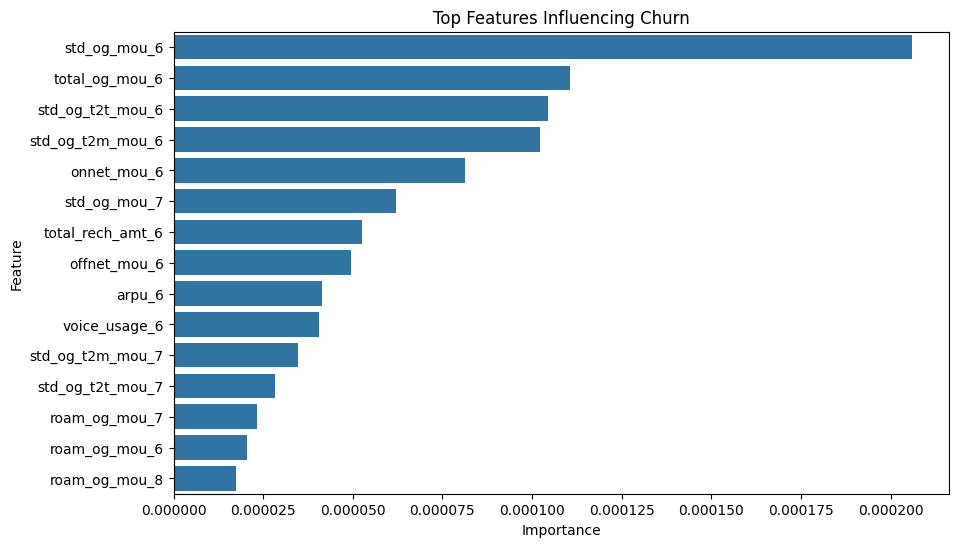

In [22]:
## visualization

import seaborn as sns
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top Features Influencing Churn")
plt.show()

#### Phase6 - choosing the right metric --> model eval with recall

In [24]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

In [25]:
## predict on test data

y_pred = rf_model.predict(X_test_pca)

In [26]:
print(confusion_matrix(y_test, y_pred))

[[4081 1403]
 [  99  420]]


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.74      0.84      5484
           1       0.23      0.81      0.36       519

    accuracy                           0.75      6003
   macro avg       0.60      0.78      0.60      6003
weighted avg       0.91      0.75      0.80      6003



In [28]:
## recall explicit calculation

recall = recall_score(y_test, y_pred)

print("Recall for churn class:", recall)

Recall for churn class: 0.8092485549132948


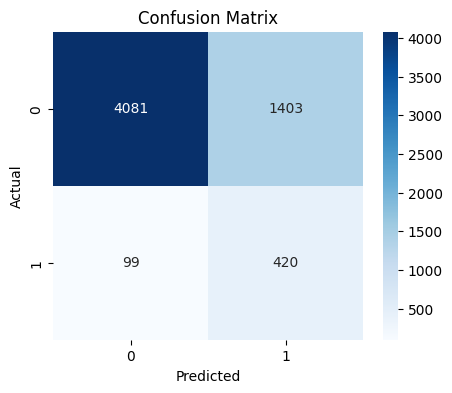

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [30]:
import joblib

In [31]:
## saving the rf models as pickle files

joblib.dump(rf_model, '../models/churn_rf_model.pkl') ## rf model

joblib.dump(scaler, '../models/scaler.pkl') ## scaler model

joblib.dump(pca, '../models/pca.pkl') ## pca model

['../models/pca.pkl']

In [32]:
## saving the logistic regression models as pkl files

joblib.dump(log_model, "../models/logistic_churn_model.pkl")

feature_names = X_train_res.columns

joblib.dump(feature_names, "../models/feature_names.pkl")

['../models/feature_names.pkl']